# Brand clustering

Category-level clusters in the brand embedding space.


## Setup


In [1]:
from pathlib import Path
import os
import re
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden.*", category=UserWarning)
from collections import Counter
from itertools import combinations

CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name == "step_4_clustering" else CWD

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from PIL import Image
from tqdm.auto import tqdm

import sklearn
from sklearn.cluster import AgglomerativeClustering, HDBSCAN, KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.metrics import (
    adjusted_rand_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity
from sklearn.preprocessing import LabelEncoder, normalize

try:
    import umap
except Exception:
    umap = None

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
RNG_SEED = 42
print("Project root: .")
print("UMAP:", getattr(umap, "__version__", "not installed"))
print("scikit-learn:", sklearn.__version__)

source_path = ROOT / "helpers" / "source_helpers.py"
exec(compile(source_path.read_text(encoding="utf-8"), str(source_path), "exec"), globals())


Project root: .
UMAP: 0.5.12
scikit-learn: 1.6.1


## Data

Embeddings aligned with the brand rows.


In [2]:
CSV_FILES = final_dataset_paths(ROOT)
VIBE_COLS = ["aesthetic_keywords", "silhouettes", "materials", "palette"]

source_rows, row_embeddings, resolved_embedding_dir = load_embeddings(ROOT)
model_name = embedding_model_name(ROOT)
source_rows = source_rows.reset_index(drop=True)
source_rows["row_id"] = np.arange(len(source_rows))

assert len(source_rows) == len(row_embeddings), (
    f"metadata rows ({len(source_rows):,}) do not match embedding rows ({len(row_embeddings):,})."
)

print(f"Embedding source: {resolved_embedding_dir.relative_to(ROOT)}")
print(f"Loaded {len(source_rows):,} embedded brand rows")
print(f"Embedding model: {model_name}")
print(f"Embedding matrix: {row_embeddings.shape}")
display(source_rows["category"].value_counts().rename_axis("category").reset_index(name="rows"))


Embedding source: step_2_text_embeddings
Loaded 1,689 embedded brand rows
Embedding model: unknown
Embedding matrix: (1689, 768)


,category,rows
0,clothes,746
1,jewellery,326
2,shoes,316
3,bags,301


## Helpers

Clustering helpers and the small hand-labelled validation groups.


In [3]:
from pathlib import Path

CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name == "step_4_clustering" else CWD
STEP_DIR = ROOT / "step_4_clustering"

helper_path = STEP_DIR / "helpers" / "clustering_helpers.py"
exec(compile(helper_path.read_text(encoding="utf-8"), str(helper_path), "exec"), globals())


## Dataset and validation tables

This section recomputes counts and validation tables from the saved dataset and embeddings.


In [4]:
import runpy

counts_table = dataset_category_counts(ROOT)
validation_family_table = validation_families_table(ROOT)
embedding_validation_table = compute_embedding_validation_summary(ROOT)

save_table(counts_table, "dataset_category_counts", ROOT)
save_table(validation_family_table, "manual_validation_families", ROOT)
save_table(embedding_validation_table, "embedding_validation", ROOT)
embedding_validation_table.to_csv(thesis_figures_dir(ROOT) / "embedding_validation_summary.csv", index=False)
runpy.run_path(str(ROOT / "step_4_clustering" / "helpers" / "figure_exports" / "embedding_validation_figure.py"), run_name="__main__")

print("Dataset counts")
display(counts_table)
print("Manual validation families")
display(validation_family_table)
print("Embedding validation summary")
display(embedding_validation_table)


Dataset counts


,category,rows
0,Clothes,746
1,Shoes,316
2,Bags,301
3,Jewellery,326


Manual validation families


,category,validation family,brands included
0,Clothes,Minimal quiet,The Row; Toteme; Jil Sander
1,Clothes,Romantic feminine,LoveShackFancy; Cecilie Bahnsen; Simone Rocha;...
2,Clothes,Graphic streetwear,Supreme; Stussy; Denim Tears; Awake NY
3,Clothes,Playful colour,Farm Rio; Ganni; Damson Madder
4,Shoes,Minimal quiet,The Row; Toteme; Jil Sander
5,Shoes,Outdoor technical,Salomon; Merrell; Sorel; Inuikii
6,Shoes,Feminine polished,Aeyde; Dear Frances; Manolo Blahnik; Aquazzura
7,Shoes,Casual everyday,Veja; Cariuma; Camper
8,Shoes,Heritage luxury,Brunello Cucinelli; Tod's
9,Bags,Sculptural contemporary,Mansur Gavriel; Staud; Cult Gaia; Jacquemus


Embedding validation summary


,category,brands,families,same_distance,different_distance,p_at_k_i,ari,nmi,missing_validation_brands
0,Clothes,14,4,0.088278,0.176817,0.785714,0.792237,0.883241,
1,Shoes,16,5,0.081056,0.145542,0.635417,0.396853,0.738324,
2,Bags,17,4,0.064005,0.143624,0.705882,0.517886,0.676100,
3,Jewellery,19,5,0.106552,0.162959,0.526316,0.621990,0.810125,


## Clothes


CATEGORY: CLOTHES


clothes: 746 unique brands; vector matrix (746, 768)


,brand_name,aesthetic_keywords,palette,moodboard
208,Damson Madder,"playful, sustainable, contemporary, print, fun","bold print, ecru, brights, floral",
259,Freenote Cloth,"heritage, workwear, craft, rugged, considered","indigo, ecru, earthy, washed",
97,Atlein,"sensual, draped, contemporary, fluid","black, ivory, deep tones",
148,Bronze 56K,"skate, lo-fi, hardware-coded, nostalgic, graphic","black, white, chrome grey, forest green, royal...",
395,Ludovic De Saint Sernin,"sensual, minimal, body-conscious, sleek, daring","black, nude tones, ivory, silver",
486,Norse Projects,"minimal, utilitarian, considered, casual","navy, ecru, olive, grey",
234,Facon Jacmin,"denim-led, conceptual, clean, polished, utilit...","indigo, ecru, black, camel",
181,Clare V,"playful, easy, casual-chic, print, bright","stripe, brights, ecru, primary",


Validation brands for clothes: 14 across 4 families


,brand_name,expected_family
10,Awake NY,Graphic streetwear
9,Denim Tears,Graphic streetwear
8,Stussy,Graphic streetwear
7,Supreme,Graphic streetwear
2,Jil Sander,Minimal quiet
0,The Row,Minimal quiet
1,Toteme,Minimal quiet
13,Damson Madder,Playful colour
11,Farm Rio,Playful colour
12,Ganni,Playful colour


...

clothes: k-means k sweep:  94%|█████████▍| 15/16 [00:10<00:00,  1.09it/s]

clothes: k-means k sweep: 100%|██████████| 16/16 [00:11<00:00,  1.02it/s]

clothes: k-means k sweep: 100%|██████████| 16/16 [00:11<00:00,  1.37it/s]

Best k by silhouette for clothes: 8
Best k by Davies-Bouldin for clothes: 17
Adaptive selected k for granular map: 18


,method,k,silhouette_cosine,davies_bouldin,min_cluster_size,clusters_lt_5,silhouette_norm,davies_bouldin_norm,granularity_norm,selection_score
11,kmeans,18,0.145821,2.357177,10,0,0.798785,0.883042,0.733333,0.815185
15,kmeans,22,0.140121,2.385054,12,0,0.661528,0.788718,1.000000,0.773739
9,kmeans,16,0.139520,2.381168,14,0,0.647063,0.801866,0.600000,0.691832
10,kmeans,17,0.128601,2.322610,23,0,0.384128,1.000000,0.666667,0.656191
14,kmeans,21,0.126208,2.384682,5,0,0.326527,0.789977,0.933333,0.610096
7,kmeans,14,0.131949,2.379418,15,0,0.464755,0.807787,0.466667,0.585199
1,kmeans,8,0.154178,2.516316,28,0,1.000000,0.344586,0.066667,0.583938
8,kmeans,15,0.124214,2.339186,17,0,0.278495,0.943914,0.533333,0.562359
13,kmeans,20,0.120453,2.388523,11,0,0.187943,0.776980,0.866667,0.529851
6,kmeans,13,0.132588,2.441470,23,0,0.480132,0.597833,0.400000,0.505301


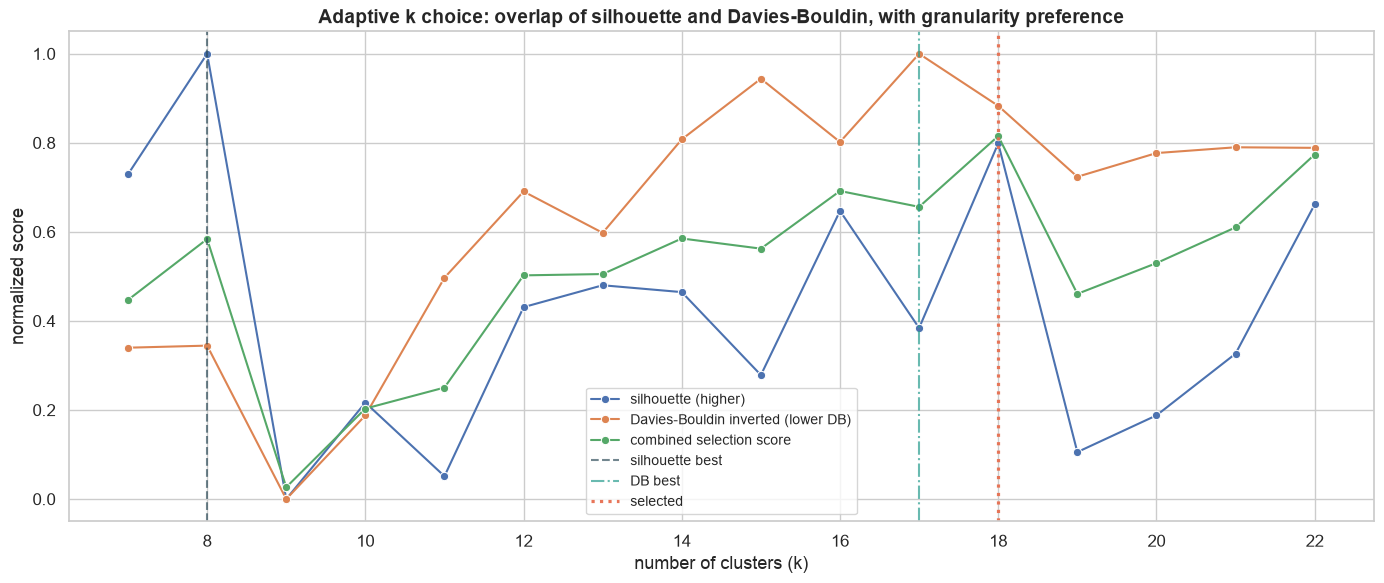

,method,n_clusters_ex_noise,noise_points,silhouette_cosine
2,sklearn.HDBSCAN,4,207,0.170261
1,agglomerative_k18,18,0,0.167845
0,kmeans_k18,18,0,0.145821


,cluster,n_brands,cluster_title,vibe_label,cluster_description,nearest_cluster,nearest_cluster_title,second_nearest_cluster,second_nearest_cluster_title,top_aesthetic_terms,supporting_terms,example_brands
7,7,89,Everyday Soft Tailoring,refined / considered,The Everyday Soft Tailoring cluster is charact...,15,Technical Utility Outerwear,8,Soft Contemporary Dressing,"refined, considered, minimal, understated, pol...","refined, tailoring, soft, trousers, relaxed, k...","Aritzia, AMI Paris, Slowear, Margaret Howell, ..."
8,8,86,Soft Contemporary Dressing,refined / considered,The Soft Contemporary Dressing cluster is char...,1,Printed Romantic Daywear,5,Glam Occasion Dresses,"refined, considered, feminine, soft, sensual, ...","soft, dresses, refined, tailoring, separates, ...","Whistles, Mes Demoiselles, By Malene Birger, D..."
1,1,64,Printed Romantic Daywear,feminine / print,The Printed Romantic Daywear cluster is charac...,8,Soft Contemporary Dressing,5,Glam Occasion Dresses,"feminine, print, playful, bold, retro, party, ...","print, dresses, bold, brights, separates, femi...","& Other Stories, Sofie Schnoor, Kitri, Rouje, ..."
16,16,53,Quiet Minimalism,sustainable / minimal,The Quiet Minimalism cluster is characterised ...,0,Relaxed Basics,8,Soft Contemporary Dressing,"sustainable, minimal, considered, soft, minima...","soft, organic, sustainable, dresses, relaxed, ...","Baukjen, Alex Crane, Albaray, Samsøe Samsøe, b..."
14,14,50,Graphic Tee Streetwear,graphic / bold,The Graphic Tee Streetwear cluster is characte...,3,Western Casual Denim,15,Technical Utility Outerwear,"graphic, bold, streetwear, playful, sensual, e...","graphic, tees, denim, nylon, brights, bold","Arte Antwerp, Carne Bollente, Pleasures, Obey,..."
5,5,48,Glam Occasion Dresses,romantic / feminine,The Glam Occasion Dresses cluster is character...,1,Printed Romantic Daywear,8,Soft Contemporary Dressing,"romantic, feminine, glamorous, polished, occas...","dresses, romantic, lace, feminine, gowns, satin","Magda Butrym, Sister Jane, Aje, Vera Wang, Val..."
10,10,44,Bohemian Craft,artisanal / bohemian,The Bohemian Craft cluster is characterised by...,1,Printed Romantic Daywear,8,Soft Contemporary Dressing,"artisanal, bohemian, resort, romantic, feminin...","dresses, print, bohemian, artisanal, embroider...","Thierry Colson, Cleobella, emporio sirenuse, A..."
12,12,43,Avant-Garde Layered Tailoring,avant garde / sculptural,The Avant-Garde Layered Tailoring cluster is c...,15,Technical Utility Outerwear,8,Soft Contemporary Dressing,"avant garde, sculptural, artful, deconstructed...","print, tailoring, sculptural, deconstructed, t...","J.W. Anderson, Comme des Garçons, zero + maria..."
0,0,42,Relaxed Basics,soft / relaxed,The Relaxed Basics cluster is characterised by...,16,Quiet Minimalism,7,Everyday Soft Tailoring,"soft, relaxed, casual, considered, minimal, ac...","soft, relaxed, separates, washed, tees, knits","Z Supply, Nude Lucy, Tee Lab, Marine Layer, Na..."
11,11,40,Denim Jeans,denim / casual,The Denim Jeans cluster is characterised by de...,3,Western Casual Denim,14,Graphic Tee Streetwear,"denim, casual, refined, cool, heritage, consid...","denim, indigo, washed, jeans, refined, separates","7 For All Mankind, Joe's Jeans, Pistola, Imoge..."


,cluster,brand_name,centroid_similarity
0,0,Z Supply,0.974858
1,0,Nude Lucy,0.974846
2,0,Tee Lab,0.971165
3,0,Marine Layer,0.970267
4,0,Native Youth,0.969964
...,...,...,...
115,8,Dorothee Schumacher,0.980184
116,8,Derek Lam,0.979947
117,8,Vanessa Bruno,0.977723
118,8,DISSH,0.976258


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


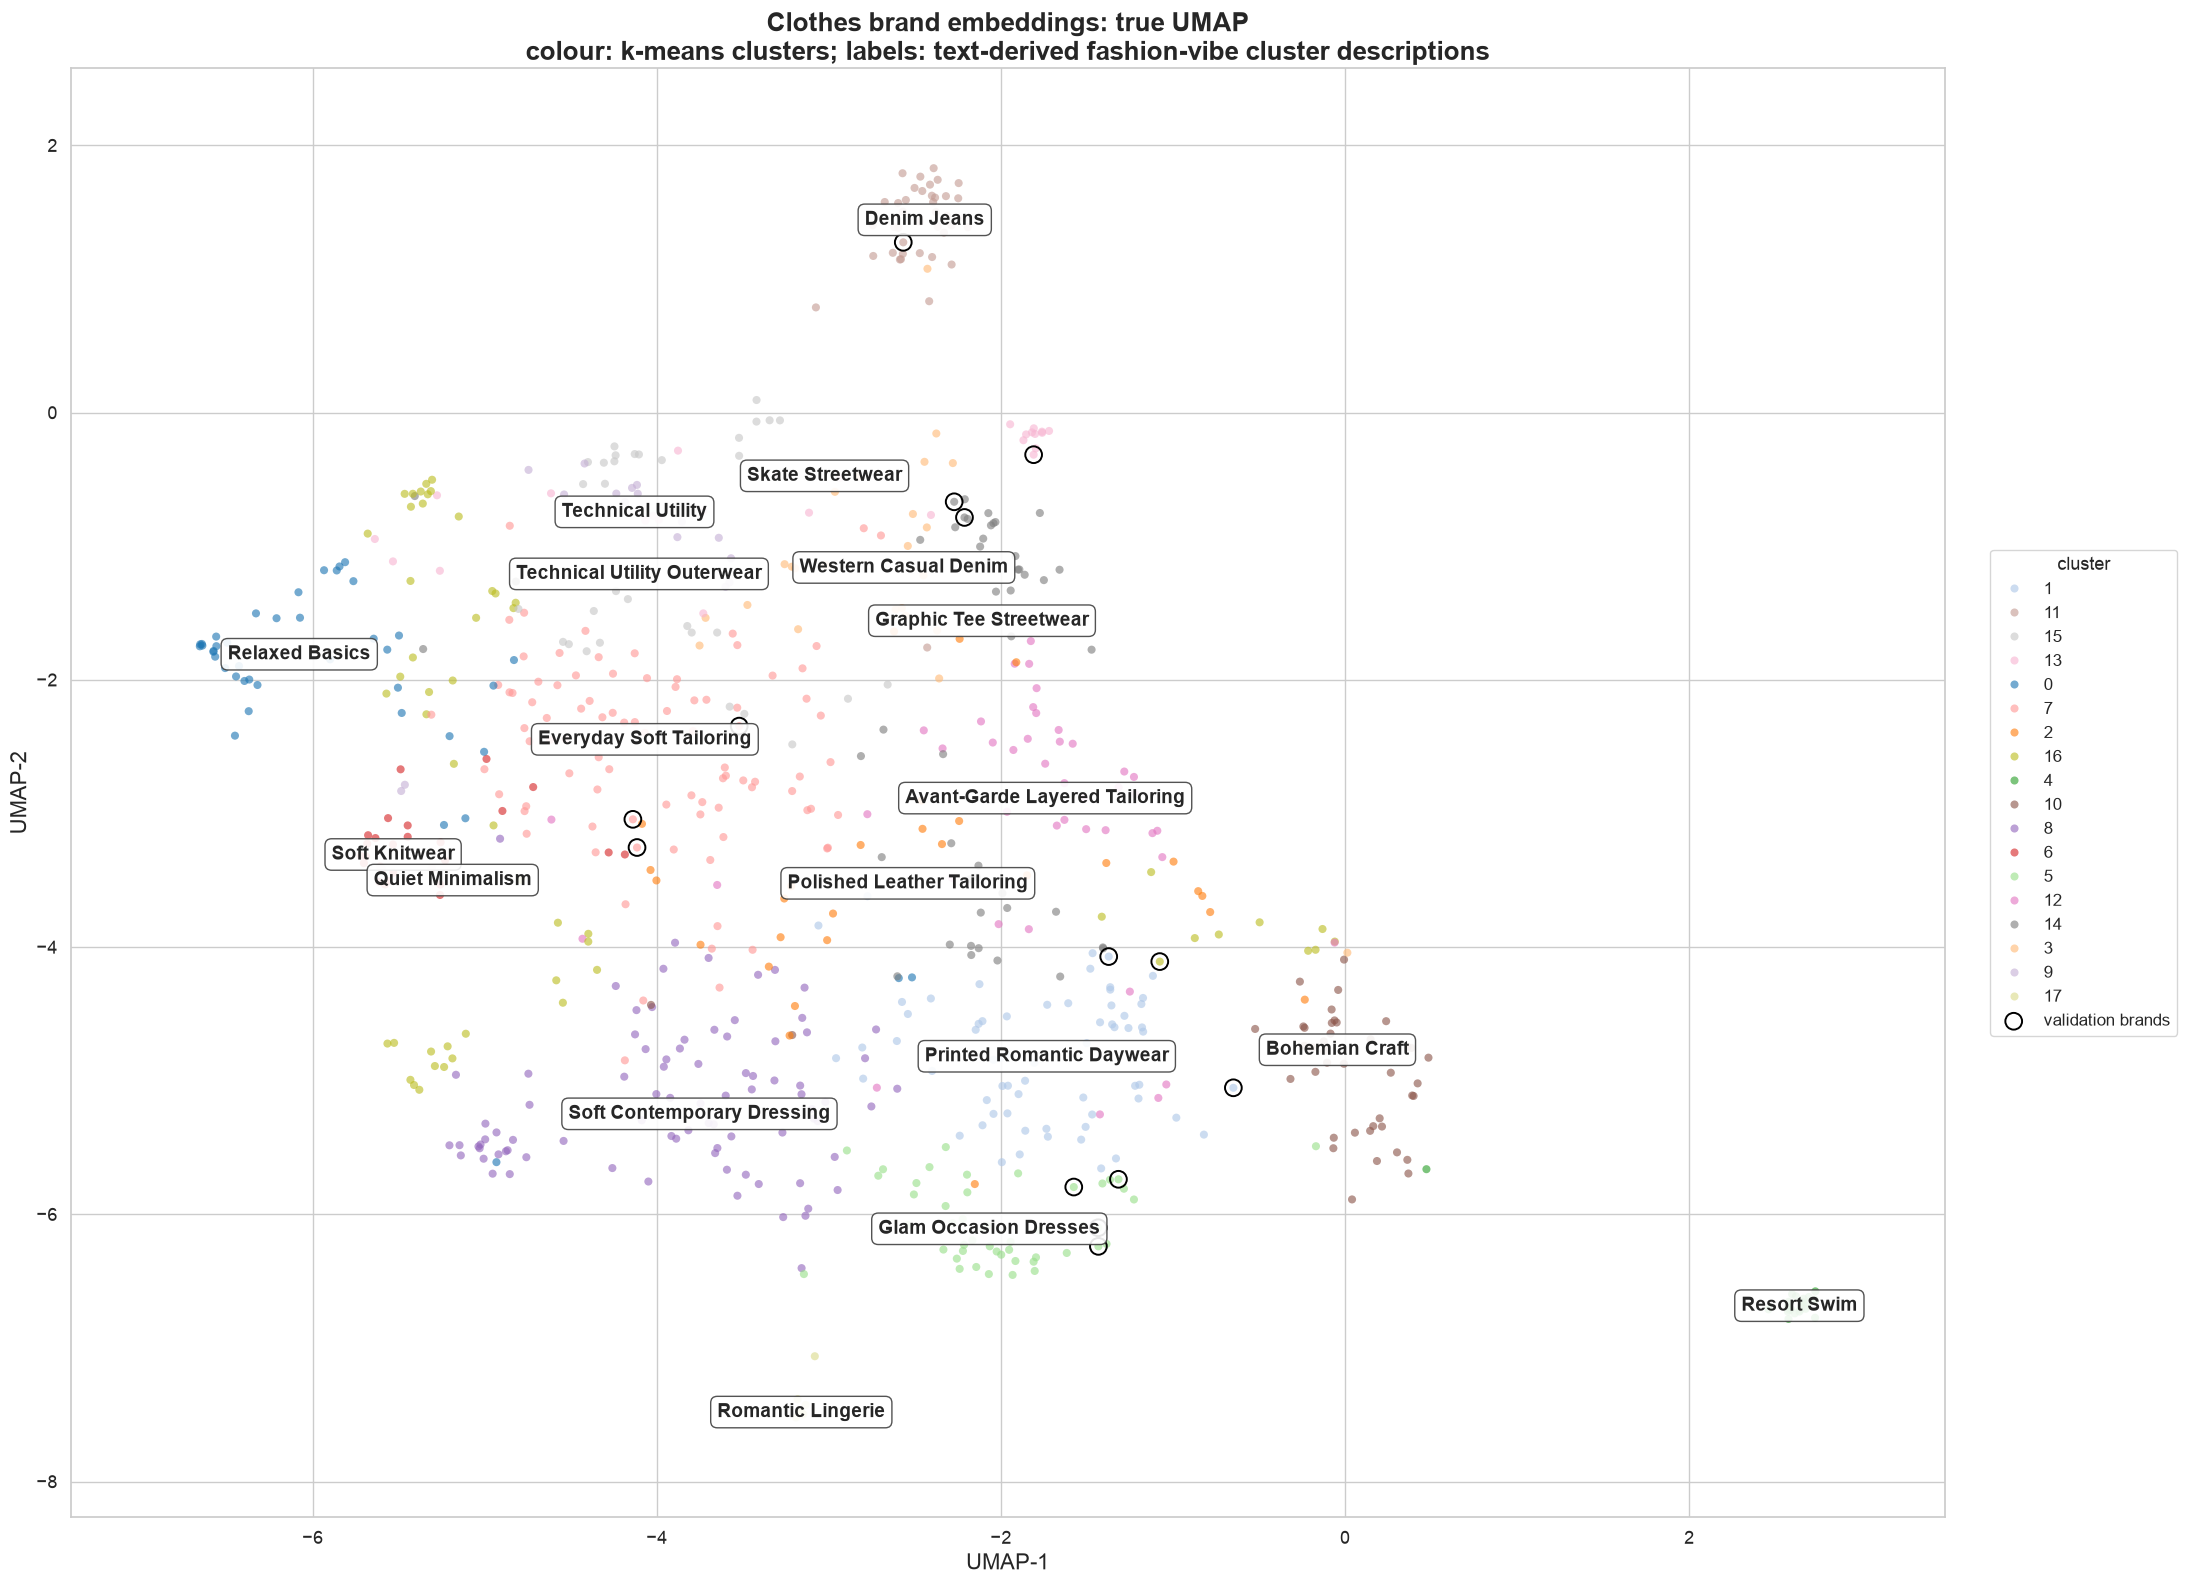

Moodboards matched for clothes: 209 representative examples


,cluster,brand_name,centroid_similarity
0,0,Z Supply,0.974858
1,0,Nude Lucy,0.974846
2,0,Tee Lab,0.971165
3,0,Marine Layer,0.970267
4,0,Native Youth,0.969964
5,0,People of Leisure,0.966597
6,0,Monrow,0.965410
7,0,Nation Ltd,0.962704
8,0,Sanctuary,0.961970
9,0,Paper Label,0.961777


In [5]:
clothes_results = run_category_analysis("clothes")


## Shoes


CATEGORY: SHOES


shoes: 316 unique brands; vector matrix (316, 768)


,brand_name,aesthetic_keywords,palette,moodboard
173,MIISTA,"artful, sculptural, bold, considered, offbeat","jewel tones, black, brights, tan",
33,Aquazzura,"glamorous, feminine, sunny, opulent, polished","nude tones, brights, black, metallic",
165,Lisa Says Gah,"playful, retro, artful, eclectic, practical","black, cream, blush, red, metallic",
78,Coperni,"futuristic, sleek, techno, minimal, practical","black, grey, white, bright accents",
93,Emerica,"skate, rugged, low-profile, padded, core","black, white, gum, olive, burgundy, muted cont...",
262,Sperry,"nautical, preppy, heritage, casual, easy","tan, navy, white, brown",
25,Amsterdam Heritage,"vintage-inspired, bohemian-refined, western-in...","tan, cream, terracotta, black",
9,Afura,"minimalist, curated, practical, tactile","black, cream, taupe, brown",


Validation brands for shoes: 16 across 5 families


,brand_name,expected_family
13,Camper,Casual everyday
12,Cariuma,Casual everyday
11,Veja,Casual everyday
7,Aeyde,Feminine polished
10,Aquazzura,Feminine polished
8,Dear Frances,Feminine polished
9,Manolo Blahnik,Feminine polished
14,Brunello Cucinelli,Heritage luxury
15,Tod's,Heritage luxury
2,Jil Sander,Minimal quiet


...

shoes: k-means k sweep:  95%|█████████▍| 18/19 [00:05<00:00,  2.45it/s]

shoes: k-means k sweep: 100%|██████████| 19/19 [00:05<00:00,  2.35it/s]

shoes: k-means k sweep: 100%|██████████| 19/19 [00:05<00:00,  3.25it/s]

Best k by silhouette for shoes: 24
Best k by Davies-Bouldin for shoes: 24
Adaptive selected k for granular map: 24


,method,k,silhouette_cosine,davies_bouldin,min_cluster_size,clusters_lt_5,silhouette_norm,davies_bouldin_norm,granularity_norm,selection_score
17,kmeans,24,0.230239,1.682616,1,5,1.000000,1.000000,0.944444,0.988889
16,kmeans,23,0.229802,1.696309,2,6,0.993971,0.981813,0.888889,0.968699
15,kmeans,22,0.222015,1.728958,2,5,0.886539,0.938449,0.833333,0.894067
18,kmeans,25,0.203146,1.809619,2,6,0.626221,0.831316,1.000000,0.772760
11,kmeans,18,0.214087,1.805031,2,2,0.777156,0.837410,0.611111,0.765036
14,kmeans,21,0.196152,1.822952,2,4,0.529725,0.813607,0.777778,0.678694
10,kmeans,17,0.199718,1.865083,3,2,0.578922,0.757649,0.555556,0.636803
13,kmeans,20,0.194750,1.922308,4,1,0.510387,0.681644,0.722222,0.612694
12,kmeans,19,0.188137,1.892155,2,2,0.419141,0.721693,0.666667,0.574539
8,kmeans,15,0.194675,1.934279,3,2,0.509344,0.665745,0.444444,0.551104


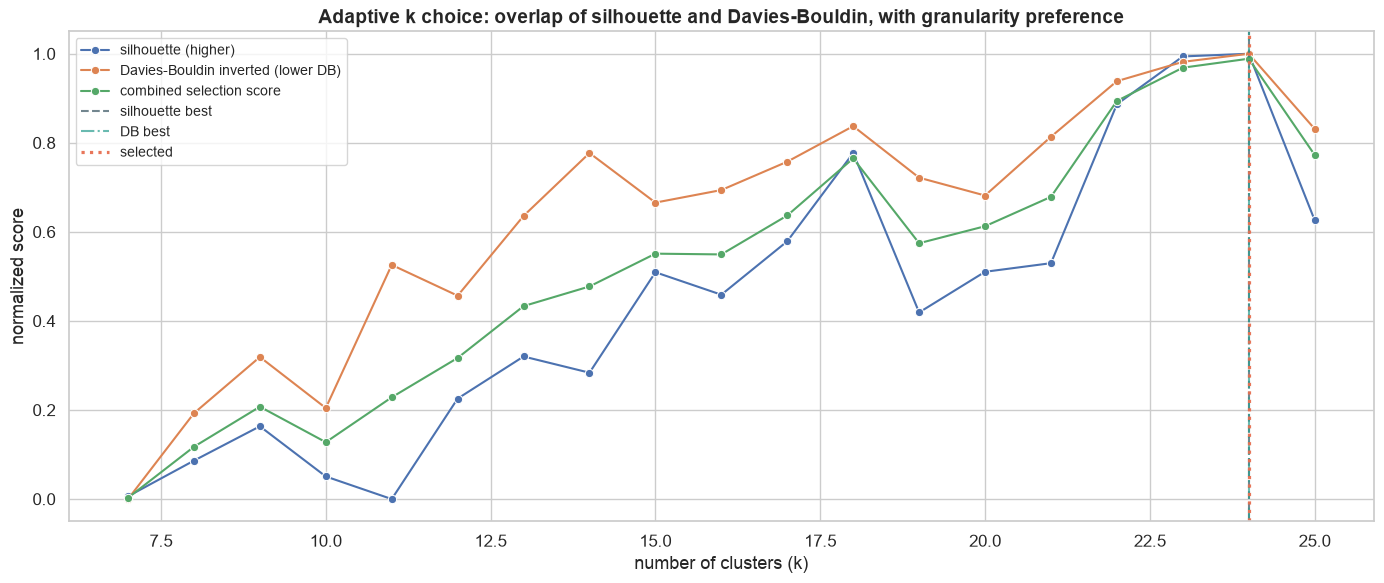

,method,n_clusters_ex_noise,noise_points,silhouette_cosine
2,sklearn.HDBSCAN,12,147,0.466108
1,agglomerative_k24,24,0,0.231993
0,kmeans_k24,24,0,0.230239


,cluster,n_brands,cluster_title,vibe_label,cluster_description,nearest_cluster,nearest_cluster_title,second_nearest_cluster,second_nearest_cluster_title,top_aesthetic_terms,supporting_terms,example_brands
4,4,35,Minimal Ballet Flats,practical / minimal,The Minimal Ballet Flats cluster is characteri...,8,Refined Sculptural Shoes,1,Everyday Leather Staples,"practical, minimal, tactile, clean, considered...","clean, boots, sandals, loafers, ballet, flats","Filippa K, vince, Jil Sander, Afura, ST.AGNI"
7,7,28,Outdoor Sport Footwear,practical / outdoor,The Outdoor Sport Footwear cluster is characte...,3,Graphic Chunky Footwear,1,Everyday Leather Staples,"practical, outdoor, utilitarian, sleek, techni...","technical, boots, rugged, sneakers, rubber, sport","Kavu, L.L.Bean, Kappa, Altra, DKNY"
1,1,25,Everyday Leather Staples,practical / tactile,The Everyday Leather Staples cluster is charac...,4,Minimal Ballet Flats,6,Trend Statement Shoes,"practical, tactile, refined, playful, consider...","boots, sandals, suede, rubber, loafers, pumps","AMI Paris, Longchamp, Whistles, Favorite Daugh..."
11,11,23,Playful Ballet Flats,practical / playful,The Playful Ballet Flats cluster is characteri...,6,Trend Statement Shoes,5,Artisanal Woven Sandals,"practical, playful, feminine, retro, romantic,...","boots, suede, flats, sandals, ballet, satin","Sofie Schnoor, Lisa Says Gah, Shrimps, Marc Ja..."
3,3,22,Graphic Chunky Footwear,practical / graphic,The Graphic Chunky Footwear cluster is charact...,7,Outdoor Sport Footwear,17,Retro Clean Trainers,"practical, graphic, street refined, playful, d...","sneakers, boots, rubber, chunky, graphic, loafers","Off-White, All Saints, Ksubi, Natasha Zinko, A..."
5,5,22,Artisanal Woven Sandals,practical / artisanal,The Artisanal Woven Sandals cluster is charact...,22,Relaxed Resort Sandals,1,Everyday Leather Staples,"practical, artisanal, bohemian, handcrafted, r...","woven, sandals, suede, boots, tan, terracotta","Guadalupe Design, Chopova Lowena, Global Mamas..."
2,2,20,Formal Leather Loafers,refined / polished,The Formal Leather Loafers cluster is characte...,4,Minimal Ballet Flats,8,Refined Sculptural Shoes,"refined, polished, heritage, considered, sarto...","loafers, flats, boots, clean, sandals, ballet","Bruno Magli, SANTONI, Johnston & Murphy, MAGNA..."
0,0,19,Embellished Occasion Heels,feminine / practical,The Embellished Occasion Heels cluster is char...,15,Refined Sculptural Heels,11,Playful Ballet Flats,"feminine, practical, romantic, occasion, glamo...","satin, embellished, sandals, heels, pumps, met...","Bernadette, Valentino, The Attico, Sachin & Ba..."
8,8,19,Refined Sculptural Shoes,considered / refined,The Refined Sculptural Shoes cluster is charac...,6,Trend Statement Shoes,4,Minimal Ballet Flats,"considered, refined, sculptural, minimal, comf...","refined, tan, suede, considered, flats, clean","Maguire, Flattered, L'Intervalle, Dear Frances..."
6,6,15,Trend Statement Shoes,trend / polished,The Trend Statement Shoes cluster is character...,8,Refined Sculptural Shoes,11,Playful Ballet Flats,"trend, polished, statement, bold, approachable...","boots, suede, sandals, nude, tan, statement","TONY BIANCO, Dune London, BILLINI, Charles & K..."


,cluster,brand_name,centroid_similarity
0,0,Bernadette,0.989341
1,0,Valentino,0.988146
2,0,The Attico,0.986825
3,0,Sachin & Babi,0.986476
4,0,Vera Wang,0.986061
...,...,...,...
115,8,Dear Frances,0.973930
116,8,Neous,0.973858
117,8,Cordani,0.973269
118,8,Freda Salvador,0.973073


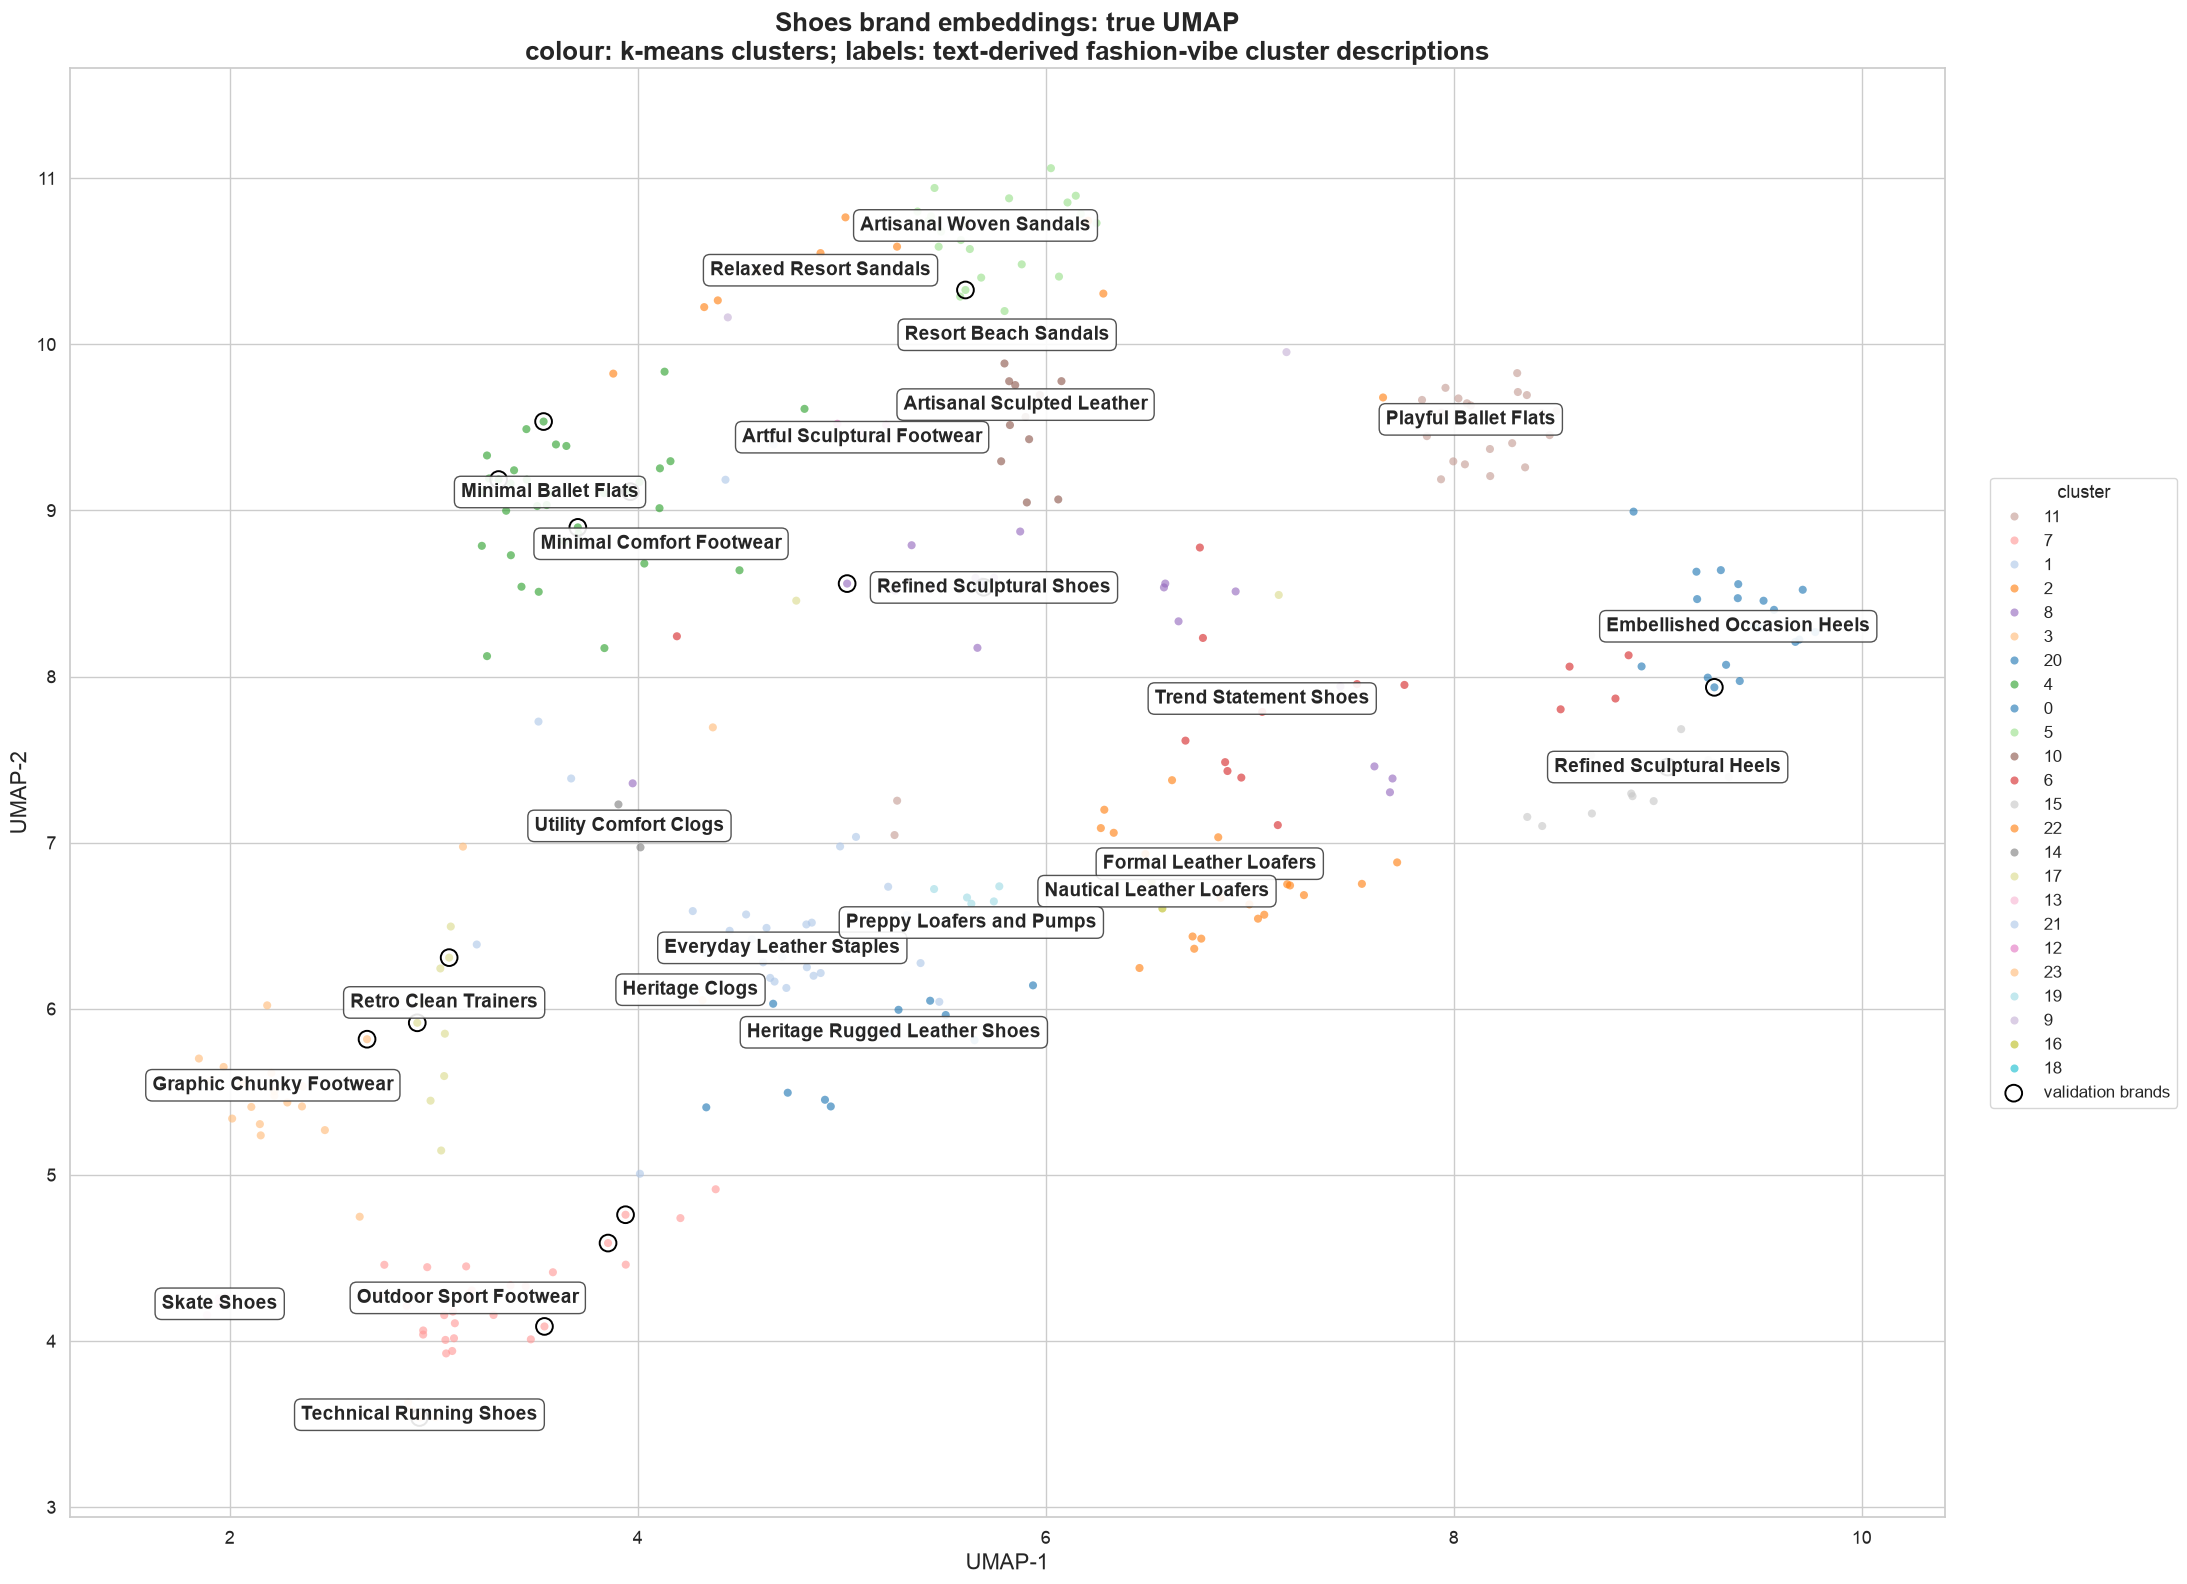

Moodboards matched for shoes: 211 representative examples


,cluster,brand_name,centroid_similarity
0,0,Bernadette,0.989341
1,0,Valentino,0.988146
2,0,The Attico,0.986825
3,0,Vera Wang,0.986061
4,0,oscar de la renta,0.978534
5,0,Laagam,0.978395
6,0,Goddiva,0.975624
7,0,Amina Muaddi,0.973097
8,0,Miu Miu,0.971986
9,0,Aquazzura,0.971356


In [6]:
# Shoes has a slightly wider k range because the first sweep landed on the upper edge.
shoes_results = run_category_analysis("shoes")


## Bags


CATEGORY: BAGS


bags: 301 unique brands; vector matrix (301, 768)


,brand_name,aesthetic_keywords,palette,moodboard
177,Murmali,"resort, artisanal, woven, sun-warmed, relaxed","black, tan, cream, seasonal colours",
289,Youths in Balaclava,"singaporean, subversive, streetwear, deconstru...","black, white, silver, graphic colours",
228,Sensi Studio,"sun-warmed, artisanal, woven, playful, easy","natural, ivory, brights, tan",
198,Percival,"playful, retro, considered, witty, detail-orie...","cream, blush, black, red, seasonal prints",
60,Cult Gaia,"sculptural, sensual, resort, statement, detail...","natural straw, tan, cream, terracotta, black",
9,Alex Mill,"utilitarian, classic, relaxed, workwear-inspir...","black, tan, cognac, cream",
118,Karhu,"sporty, Finnish, retro-athletic, technical, pr...","black, grey, navy, bright technical accents",
154,Maje,"feminine, bohemian-chic, detail-oriented, crafted","natural straw, tan, cream, terracotta, black",


Validation brands for bags: 17 across 4 families


,brand_name,expected_family
16,Bernadette,Evening glam
14,JIMMY CHOO,Evening glam
13,Miu Miu,Evening glam
15,The Attico,Evening glam
12,Valentino,Evening glam
11,Bellroy,Practical carry
9,Dagne Dover,Practical carry
10,Herschel,Practical carry
2,Cult Gaia,Sculptural contemporary
3,Jacquemus,Sculptural contemporary


...

bags: k-means k sweep:  94%|█████████▍| 15/16 [00:04<00:00,  2.80it/s]

bags: k-means k sweep: 100%|██████████| 16/16 [00:04<00:00,  2.74it/s]

bags: k-means k sweep: 100%|██████████| 16/16 [00:04<00:00,  3.50it/s]

Best k by silhouette for bags: 12
Best k by Davies-Bouldin for bags: 17
Adaptive selected k for granular map: 17


,method,k,silhouette_cosine,davies_bouldin,min_cluster_size,clusters_lt_5,silhouette_norm,davies_bouldin_norm,granularity_norm,selection_score
10,kmeans,17,0.235752,1.859586,1,1,0.908932,1.000000,0.666667,0.892353
5,kmeans,12,0.241389,1.953651,8,0,1.000000,0.699147,0.333333,0.761368
7,kmeans,14,0.228073,1.902463,6,0,0.784872,0.862863,0.466667,0.748528
6,kmeans,13,0.231897,1.949723,9,0,0.846656,0.711710,0.400000,0.710094
11,kmeans,18,0.216898,1.939185,1,1,0.604342,0.745414,0.733333,0.679515
14,kmeans,21,0.222562,2.020515,3,2,0.695841,0.485290,0.933333,0.669646
9,kmeans,16,0.223760,1.984779,4,1,0.715200,0.599586,0.600000,0.651695
8,kmeans,15,0.238971,2.099370,8,0,0.960941,0.233083,0.533333,0.620669
12,kmeans,19,0.206685,1.985647,6,0,0.439350,0.596812,0.800000,0.566592
15,kmeans,22,0.189308,1.964768,1,3,0.158612,0.663589,1.000000,0.503632


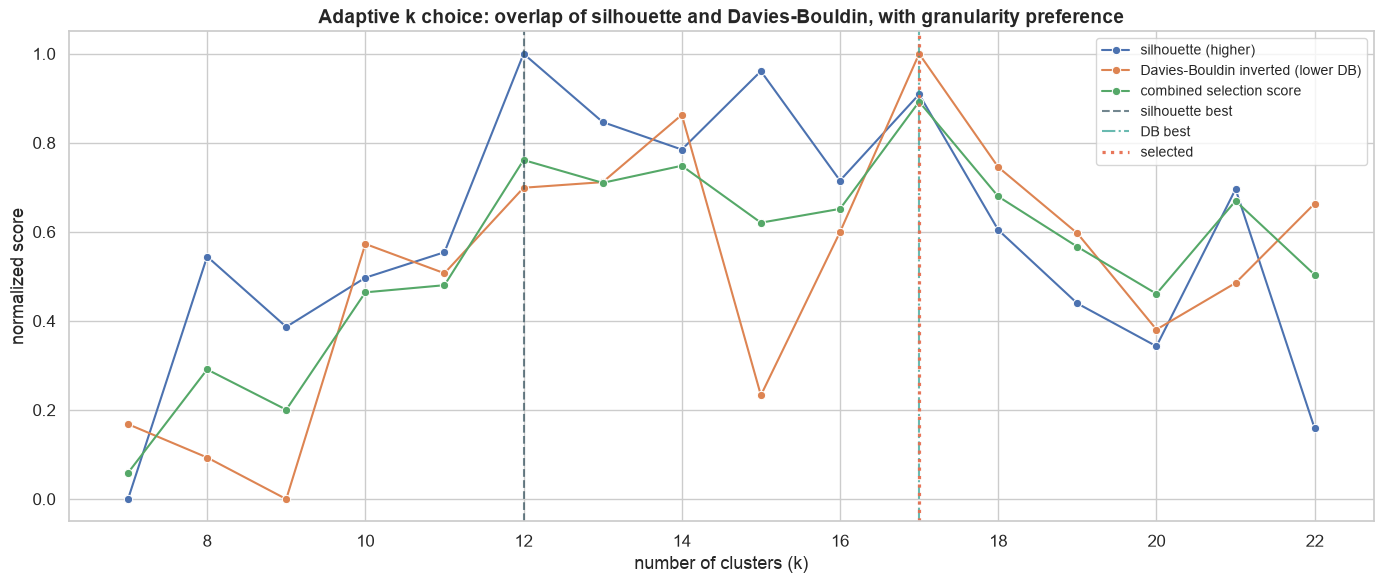

,method,n_clusters_ex_noise,noise_points,silhouette_cosine
2,sklearn.HDBSCAN,9,157,0.529555
0,kmeans_k17,17,0,0.235752
1,agglomerative_k17,17,0,0.141109


,cluster,n_brands,cluster_title,vibe_label,cluster_description,nearest_cluster,nearest_cluster_title,second_nearest_cluster,second_nearest_cluster_title,top_aesthetic_terms,supporting_terms,example_brands
12,12,36,Polished Structured Totes,polished / crafted,The Polished Structured Totes cluster is chara...,14,Feminine Structured Shoulder Bags,0,Heritage Leather Carryalls,"polished, crafted, refined, heritage, playful,...","totes, structured, hardware, shoulder, suede, tan","Favorite Daughter, L'agence, Ines de la Fressa..."
16,16,34,Everyday Pouch Bags,playful / polished,The Everyday Pouch Bags cluster is characteris...,4,Experimental Sculptural Bags,15,Artisanal Resort Carryalls,"playful, polished, practical, everyday, femini...","canvas, pouches, hardware, tan, seasonal, colours","Monade, Khakis, Summum Woman, Well Done Goods,..."
2,2,29,Minimal Structured Crossbodies,minimal / crafted,The Minimal Structured Crossbodies cluster is ...,5,Refined Sculptural Handbags,14,Feminine Structured Shoulder Bags,"minimal, crafted, clean, considered, utilitari...","minimal, clean, shoulder, totes, structured, c...","Jenni Kayne, Afura, ST.AGNI, Simon Miller, Fil..."
6,6,25,Sport Utility Backpacks,technical / sleek,The Sport Utility Backpacks cluster is charact...,1,Graphic Urban Crossbodies,3,Functional Technical Totes,"technical, sleek, sporty, outdoor, utilitarian...","technical, totes, pouches, nylon, backpacks, belt","Kappa, DKNY, SACAI, L.L.Bean, ALO YOGA"
1,1,21,Graphic Urban Crossbodies,graphic / bold,The Graphic Urban Crossbodies cluster is chara...,6,Sport Utility Backpacks,4,Experimental Sculptural Bags,"graphic, bold, urban, street refined, playful,...","totes, hardware, graphic, metal, canvas, cross...","All Saints, Off-White, Ksubi, Ambush, Juicy Co..."
11,11,20,Playful Soft Shoulder Bags,playful / retro,The Playful Soft Shoulder Bags cluster is char...,14,Feminine Structured Shoulder Bags,16,Everyday Pouch Bags,"playful, retro, feminine, eclectic, print, joy...","soft, totes, mini, shoulder, top, handle","Shrimps, Sofie Schnoor, Lisa Says Gah, Marc Ja..."
3,3,20,Functional Technical Totes,functional / practical,The Functional Technical Totes cluster is char...,6,Sport Utility Backpacks,4,Experimental Sculptural Bags,"functional, practical, minimal, considered, te...","totes, canvas, recycled, nylon, functional, ba...","Dagne Dover, Souleway, DB Journey, zero + mari..."
5,5,20,Refined Sculptural Handbags,refined / considered,The Refined Sculptural Handbags cluster is cha...,14,Feminine Structured Shoulder Bags,12,Polished Structured Totes,"refined, considered, crafted, minimal, sculptu...","refined, structured, totes, tan, clean, minimal","Maison N.H. Paris, DeMellier, Songmont, Alexan..."
14,14,17,Feminine Structured Shoulder Bags,polished / feminine,The Feminine Structured Shoulder Bags cluster ...,12,Polished Structured Totes,11,Playful Soft Shoulder Bags,"polished, feminine, sensual, crafted, soft, la...","shoulder, totes, suede, hardware, tan, crossbo...","Sezane, Jonathan Simkhai, Twinset, J.Crew, Van..."
8,8,16,Woven Natural Bags,artisanal / bohemian,The Woven Natural Bags cluster is characterise...,7,Ethical Craft Carryalls,15,Artisanal Resort Carryalls,"artisanal, bohemian, resort, sun warmed, relax...","straw, raffia, woven, totes, natural, tan","Jamie Haller, Gimaguas, Guadalupe Design, Chan..."


,cluster,brand_name,centroid_similarity
0,0,WP Standard,0.978041
1,0,Bleu De Chauffe,0.973844
2,0,Shinola,0.971423
3,0,MONTBLANC,0.968339
4,0,Jack Georges,0.967906
...,...,...,...
115,9,Laagam,0.982396
116,9,Miu Miu,0.975147
117,9,JIMMY CHOO,0.974968
118,9,Goddiva,0.970384


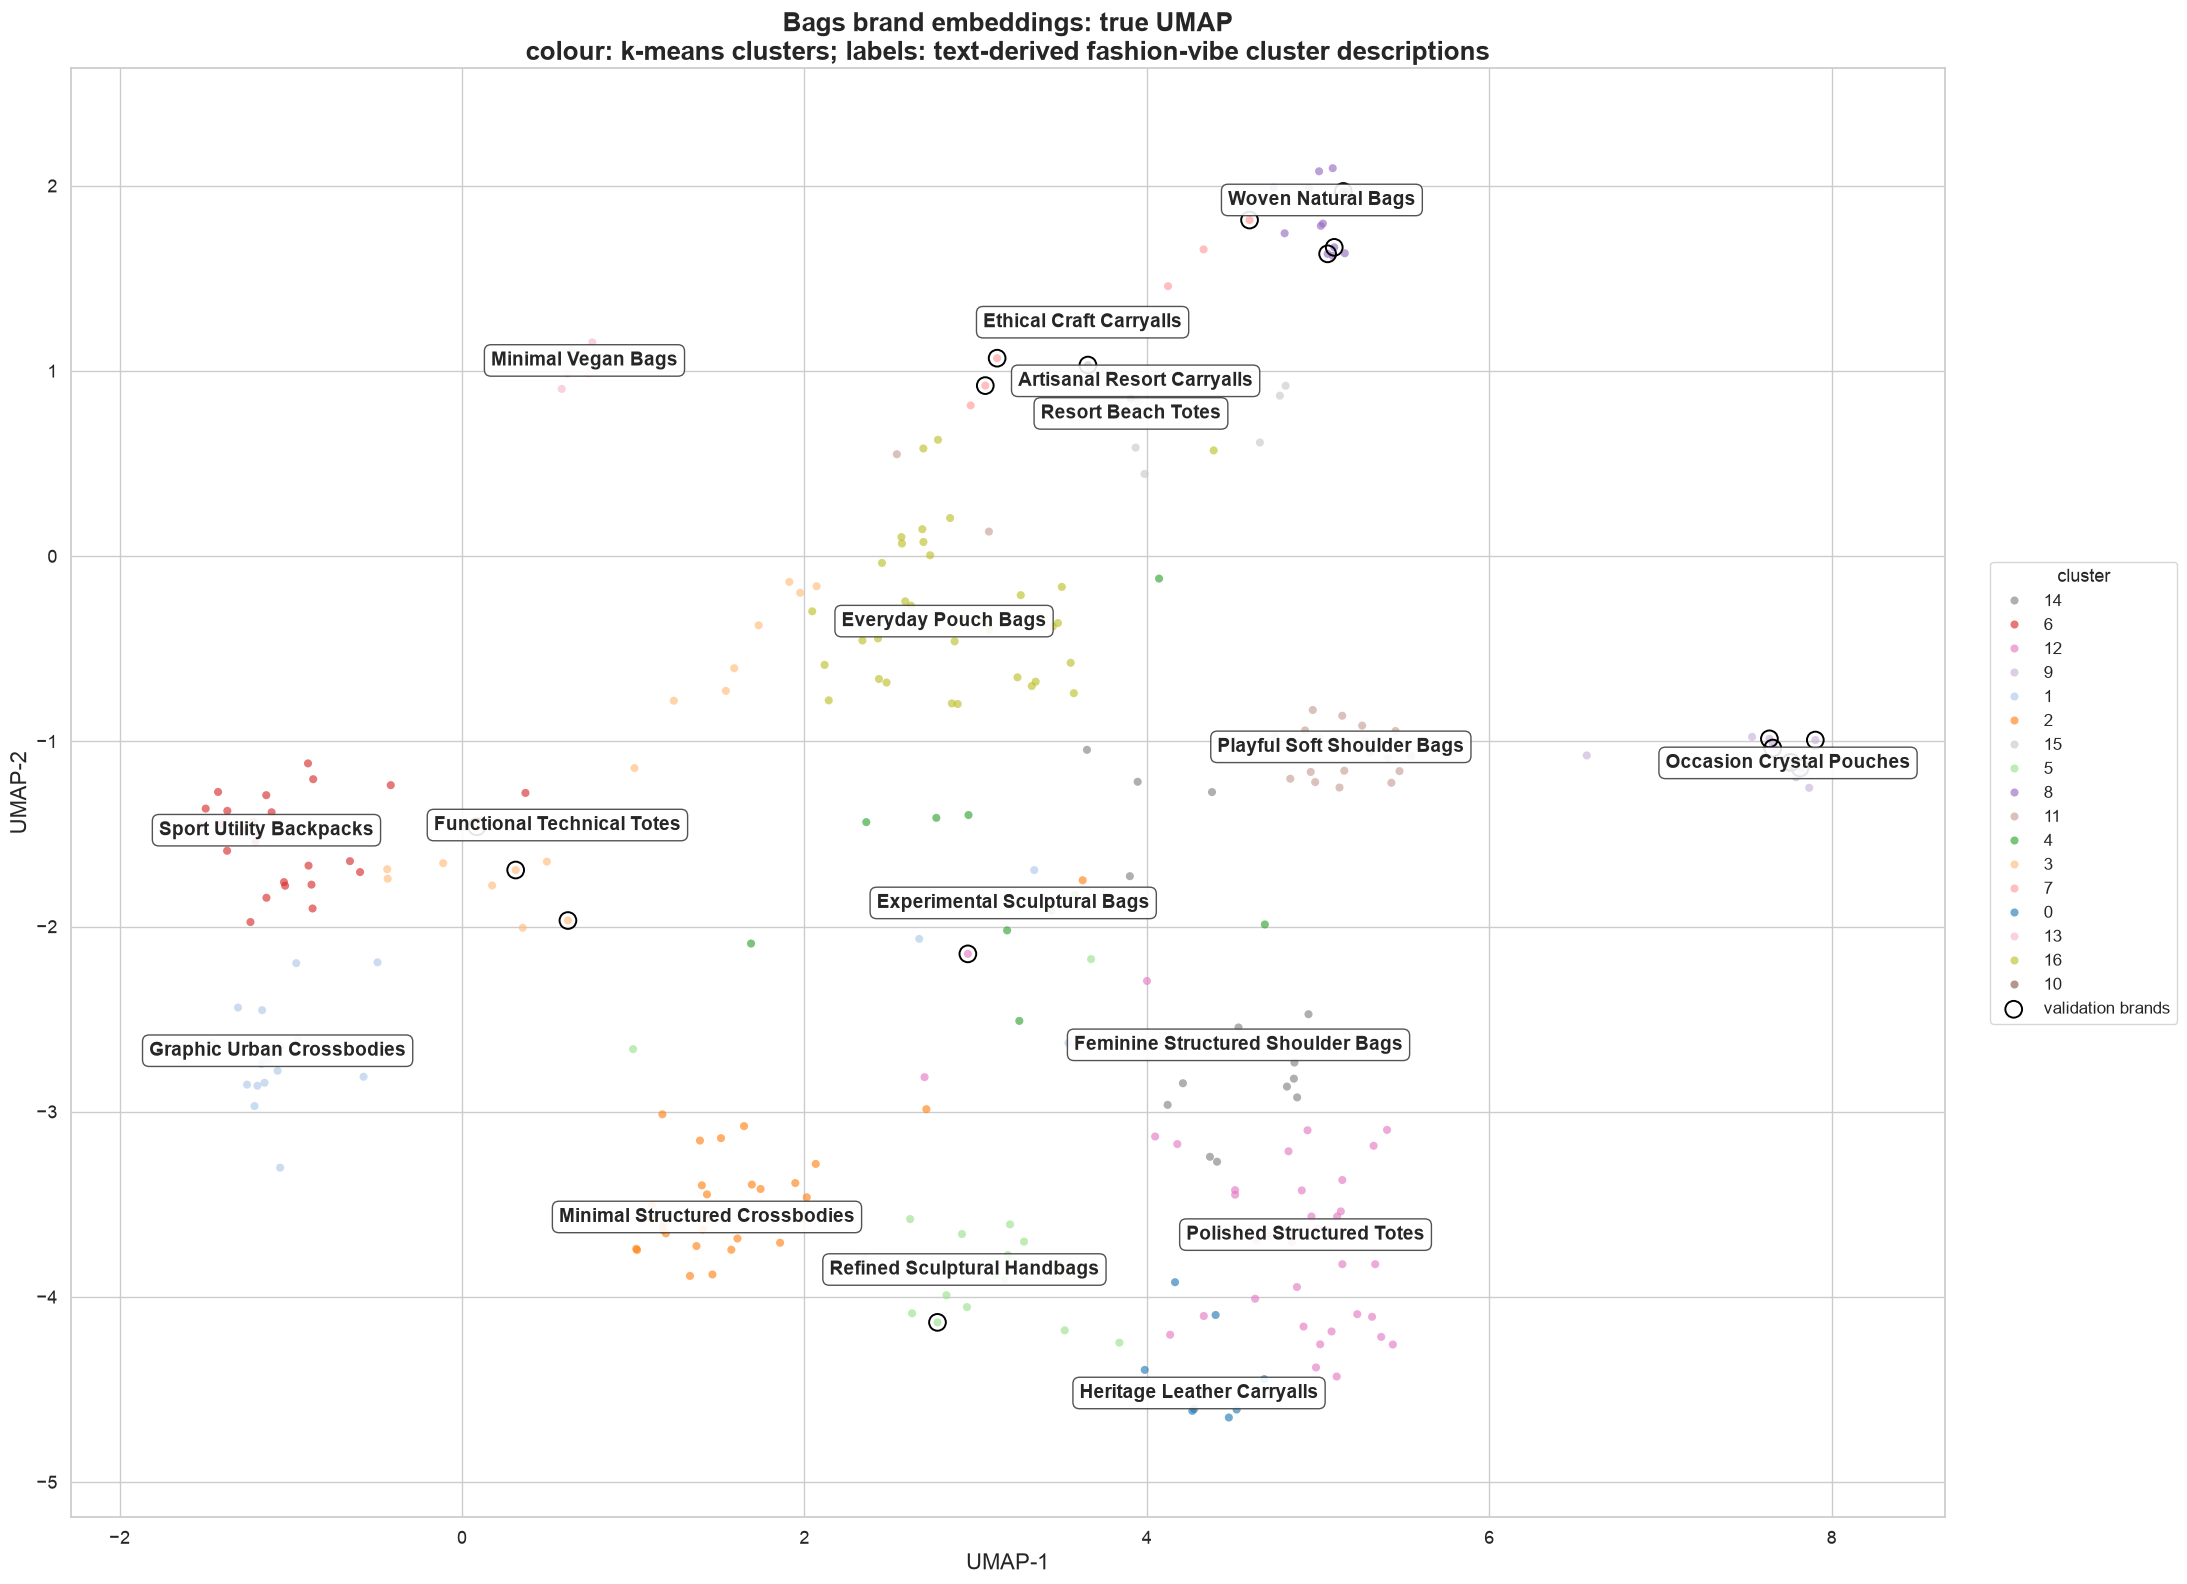

Moodboards matched for bags: 185 representative examples


,cluster,brand_name,centroid_similarity
0,0,WP Standard,0.978041
1,0,Bleu De Chauffe,0.973844
2,0,Shinola,0.971423
3,0,MONTBLANC,0.968339
4,0,Jack Georges,0.967906
5,0,Steel Horse Leather,0.965463
6,0,Mulberry,0.962041
7,0,Il Bisonte,0.960767
8,0,Johnny Farah,0.957972
9,0,Bennett Winch,0.928426


In [7]:
bags_results = run_category_analysis("bags")


## Jewellery


CATEGORY: JEWELLERY


jewellery: 326 unique brands; vector matrix (326, 768)


,brand_name,aesthetic_keywords,palette,moodboard
234,Patcharavipa,"sculptural, modern, refined, organic, considered","gold, diamond, sculptural",
110,Gabriela Hearst,"restrained refinement, considered, sustainable...","silver, gold, pearl, black",
249,Quince,"minimal, essential, approachable-refined, clea...","silver, gold, pearl, black",
9,Agmes,"sculptural, modern, minimal, art-led, sustainable","silver, gold, pearl, black",
93,Deakin And Francis,"heritage, refined, witty, crafted, classic","gold, silver, enamel",
219,Nomia,"minimal, architectural, downtown, clean, ornam...","silver, gold, pearl, black",
274,Sophie Deschamps Bijoux,"delicate, layering, feminine, polished, everyday","gold, silver, pearl, jewel tones",
198,Marlo Laz,"talismanic, sun-warmed, sensual, bohemian-fine...","gold, turquoise, vivid gemstone",


Validation brands for jewellery: 19 across 5 families


,brand_name,expected_family
4,Cartier,Fine luxury
5,David Morris,Fine luxury
6,Maria Tash,Fine luxury
3,TIFFANY & CO,Fine luxury
2,Jil Sander,Minimal quiet
0,The Row,Minimal quiet
1,Toteme,Minimal quiet
10,Alice Cicolini,Playful colour
7,Anni Lu,Playful colour
9,Irene Neuwirth,Playful colour


...

jewellery: k-means k sweep:  94%|█████████▍| 15/16 [00:05<00:00,  2.03it/s]

jewellery: k-means k sweep: 100%|██████████| 16/16 [00:05<00:00,  1.86it/s]

jewellery: k-means k sweep: 100%|██████████| 16/16 [00:05<00:00,  2.70it/s]

Best k by silhouette for jewellery: 18
Best k by Davies-Bouldin for jewellery: 16
Adaptive selected k for granular map: 16


,method,k,silhouette_cosine,davies_bouldin,min_cluster_size,clusters_lt_5,silhouette_norm,davies_bouldin_norm,granularity_norm,selection_score
9,kmeans,16,0.247916,1.900831,1,2,0.835965,1.000000,0.600000,0.846184
11,kmeans,18,0.255722,2.014722,1,2,1.000000,0.613877,0.733333,0.811524
7,kmeans,14,0.244317,1.905711,1,1,0.760342,0.983452,0.466667,0.779696
10,kmeans,17,0.250091,1.996422,2,1,0.881682,0.675920,0.666667,0.766662
12,kmeans,19,0.230393,1.917057,1,2,0.467757,0.944988,0.800000,0.701237
6,kmeans,13,0.241073,2.014908,6,0,0.692174,0.613245,0.400000,0.606114
15,kmeans,22,0.220824,1.968912,1,2,0.266681,0.769185,1.000000,0.589221
8,kmeans,15,0.239356,2.039224,3,1,0.656101,0.530810,0.533333,0.587695
14,kmeans,21,0.237491,2.133921,5,0,0.616906,0.209762,0.933333,0.537691
5,kmeans,12,0.235772,2.059066,6,0,0.580787,0.463538,0.333333,0.490259


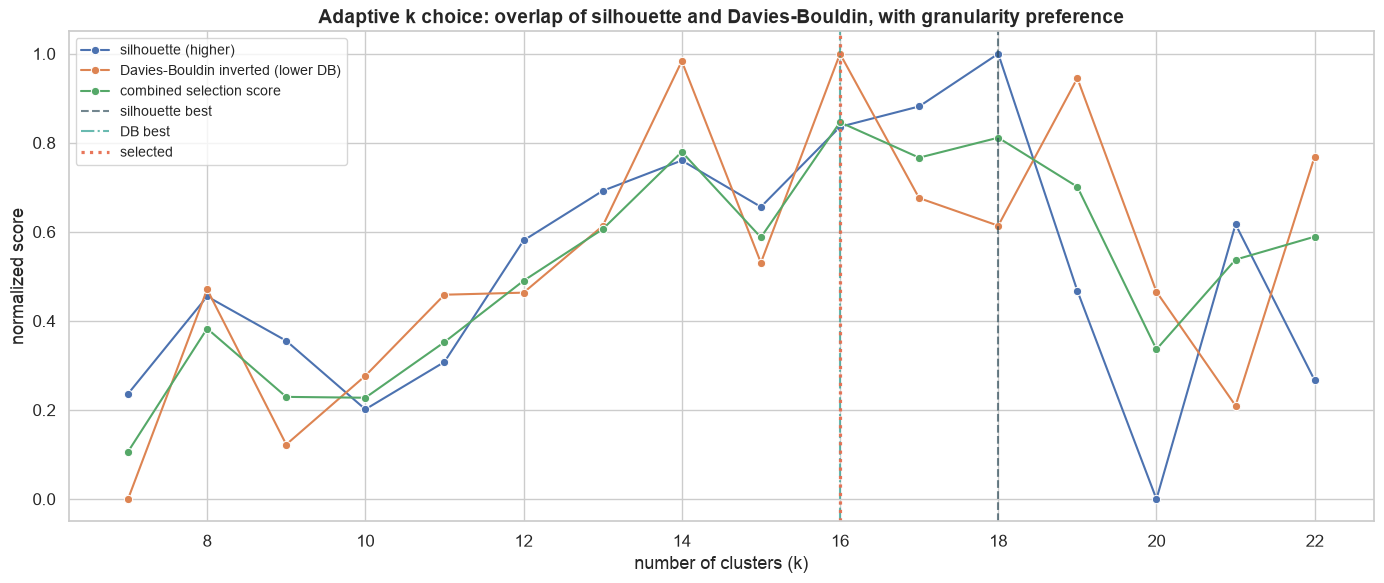

,method,n_clusters_ex_noise,noise_points,silhouette_cosine
2,sklearn.HDBSCAN,10,144,0.474340
0,kmeans_k16,16,0,0.247916
1,agglomerative_k16,16,0,0.134945


,cluster,n_brands,cluster_title,vibe_label,cluster_description,nearest_cluster,nearest_cluster_title,second_nearest_cluster,second_nearest_cluster_title,top_aesthetic_terms,supporting_terms,example_brands
2,2,41,Bold Sculptural Hoops,ornamental / sculptural,The Bold Sculptural Hoops cluster is character...,3,Polished Pearl Jewellery,15,Playful Charm Jewellery,"ornamental, sculptural, bold, sleek, minimal, ...","rings, hoops, metal, chains, tone, sterling","All Saints, Natasha Zinko, Ksubi, Maison Kitsu..."
3,3,34,Polished Pearl Jewellery,ornamental / sculptural,The Polished Pearl Jewellery cluster is charac...,15,Playful Charm Jewellery,2,Bold Sculptural Hoops,"ornamental, sculptural, polished, refined, her...","pearl, rings, earrings, pearls, hoops, chains","AMI Paris, Staud, L'agence, Favorite Daughter,..."
4,4,30,Bohemian Beaded Jewellery,ornamental / artisanal,The Bohemian Beaded Jewellery cluster is chara...,15,Playful Charm Jewellery,3,Polished Pearl Jewellery,"ornamental, artisanal, bohemian, colourful, pl...","beaded, necklaces, bracelets, beads, organic, ...","Jamie Haller, Chan Luu, Calleen Cordero, Amste..."
15,15,29,Playful Charm Jewellery,ornamental / playful,The Playful Charm Jewellery cluster is charact...,14,Crystal Occasion Jewellery,3,Polished Pearl Jewellery,"ornamental, playful, feminine, retro, eclectic...","tone, metal, charm, necklaces, rings, enamel","Lisa Says Gah, Sofie Schnoor, Shrimps, Marc Ja..."
6,6,27,Minimal Sculptural Jewellery,ornamental / sculptural,The Minimal Sculptural Jewellery cluster is ch...,2,Bold Sculptural Hoops,3,Polished Pearl Jewellery,"ornamental, sculptural, minimal, restrained re...","clean, slim, rings, simple, chains, cuffs","ST.AGNI, vince, Jil Sander, Afura, Filippa K"
12,12,27,Opulent Gemstone Fine Jewellery,refined / fine,The Opulent Gemstone Fine Jewellery cluster is...,1,Delicate Fine Chains,9,Talismanic Gemstone Jewellery,"refined, fine, opulent, sparkling, sensual, bo...","fine, gemstone, diamonds, diamond, rings, gems...","Piaget, Viltier, PDPAOLA, Marlo Laz, ANNA + NINA"
11,11,25,Sculptural Chain Jewellery,sculptural / artful,The Sculptural Chain Jewellery cluster is char...,10,Organic Sculptural Rings,2,Bold Sculptural Hoops,"sculptural, artful, bold, considered, layering...","sculptural, chains, bold, fine, sterling, pearls","Sophie Buhai, Leigh Miller, Wouters & Hendrix,..."
8,8,22,Utility Metal Charms,ornamental / utilitarian,The Utility Metal Charms cluster is characteri...,2,Bold Sculptural Hoops,5,Talismanic Enamel Jewellery,"ornamental, utilitarian, sculptural, technical...","logo, charms, simple, pendants, understated, r...","Alex Mill, Kavu, L.L.Bean, Caron Callahan, C.P..."
1,1,21,Delicate Fine Chains,refined / delicate,The Delicate Fine Chains cluster is characteri...,12,Opulent Gemstone Fine Jewellery,10,Organic Sculptural Rings,"refined, delicate, everyday fine, fine, consid...","fine, gemstone, refined, delicate, chains, gem...","Jennifer Meyer, Azlee, Anne Sportun, Zoe Chicc..."
14,14,19,Crystal Occasion Jewellery,ornamental / romantic,The Crystal Occasion Jewellery cluster is char...,15,Playful Charm Jewellery,3,Polished Pearl Jewellery,"ornamental, romantic, sparkling, occasion, gla...","crystal, tone, metal, earrings, pearl, pearls","The Attico, Vera Wang, Bernadette, Sachin & Ba..."


,cluster,brand_name,centroid_similarity
0,0,YOKO LONDON,0.979588
1,0,Perle by Lola,0.971684
2,0,Blue Ocean Traders,0.970633
3,0,Sophie Bille Brahe,0.967311
4,0,Mikimoto,0.964757
...,...,...,...
115,9,Melissa Joy Manning,0.944315
116,9,Dana Kellin,0.939871
117,9,Pamela Love,0.923770
118,10,Loren Stewart,0.972015


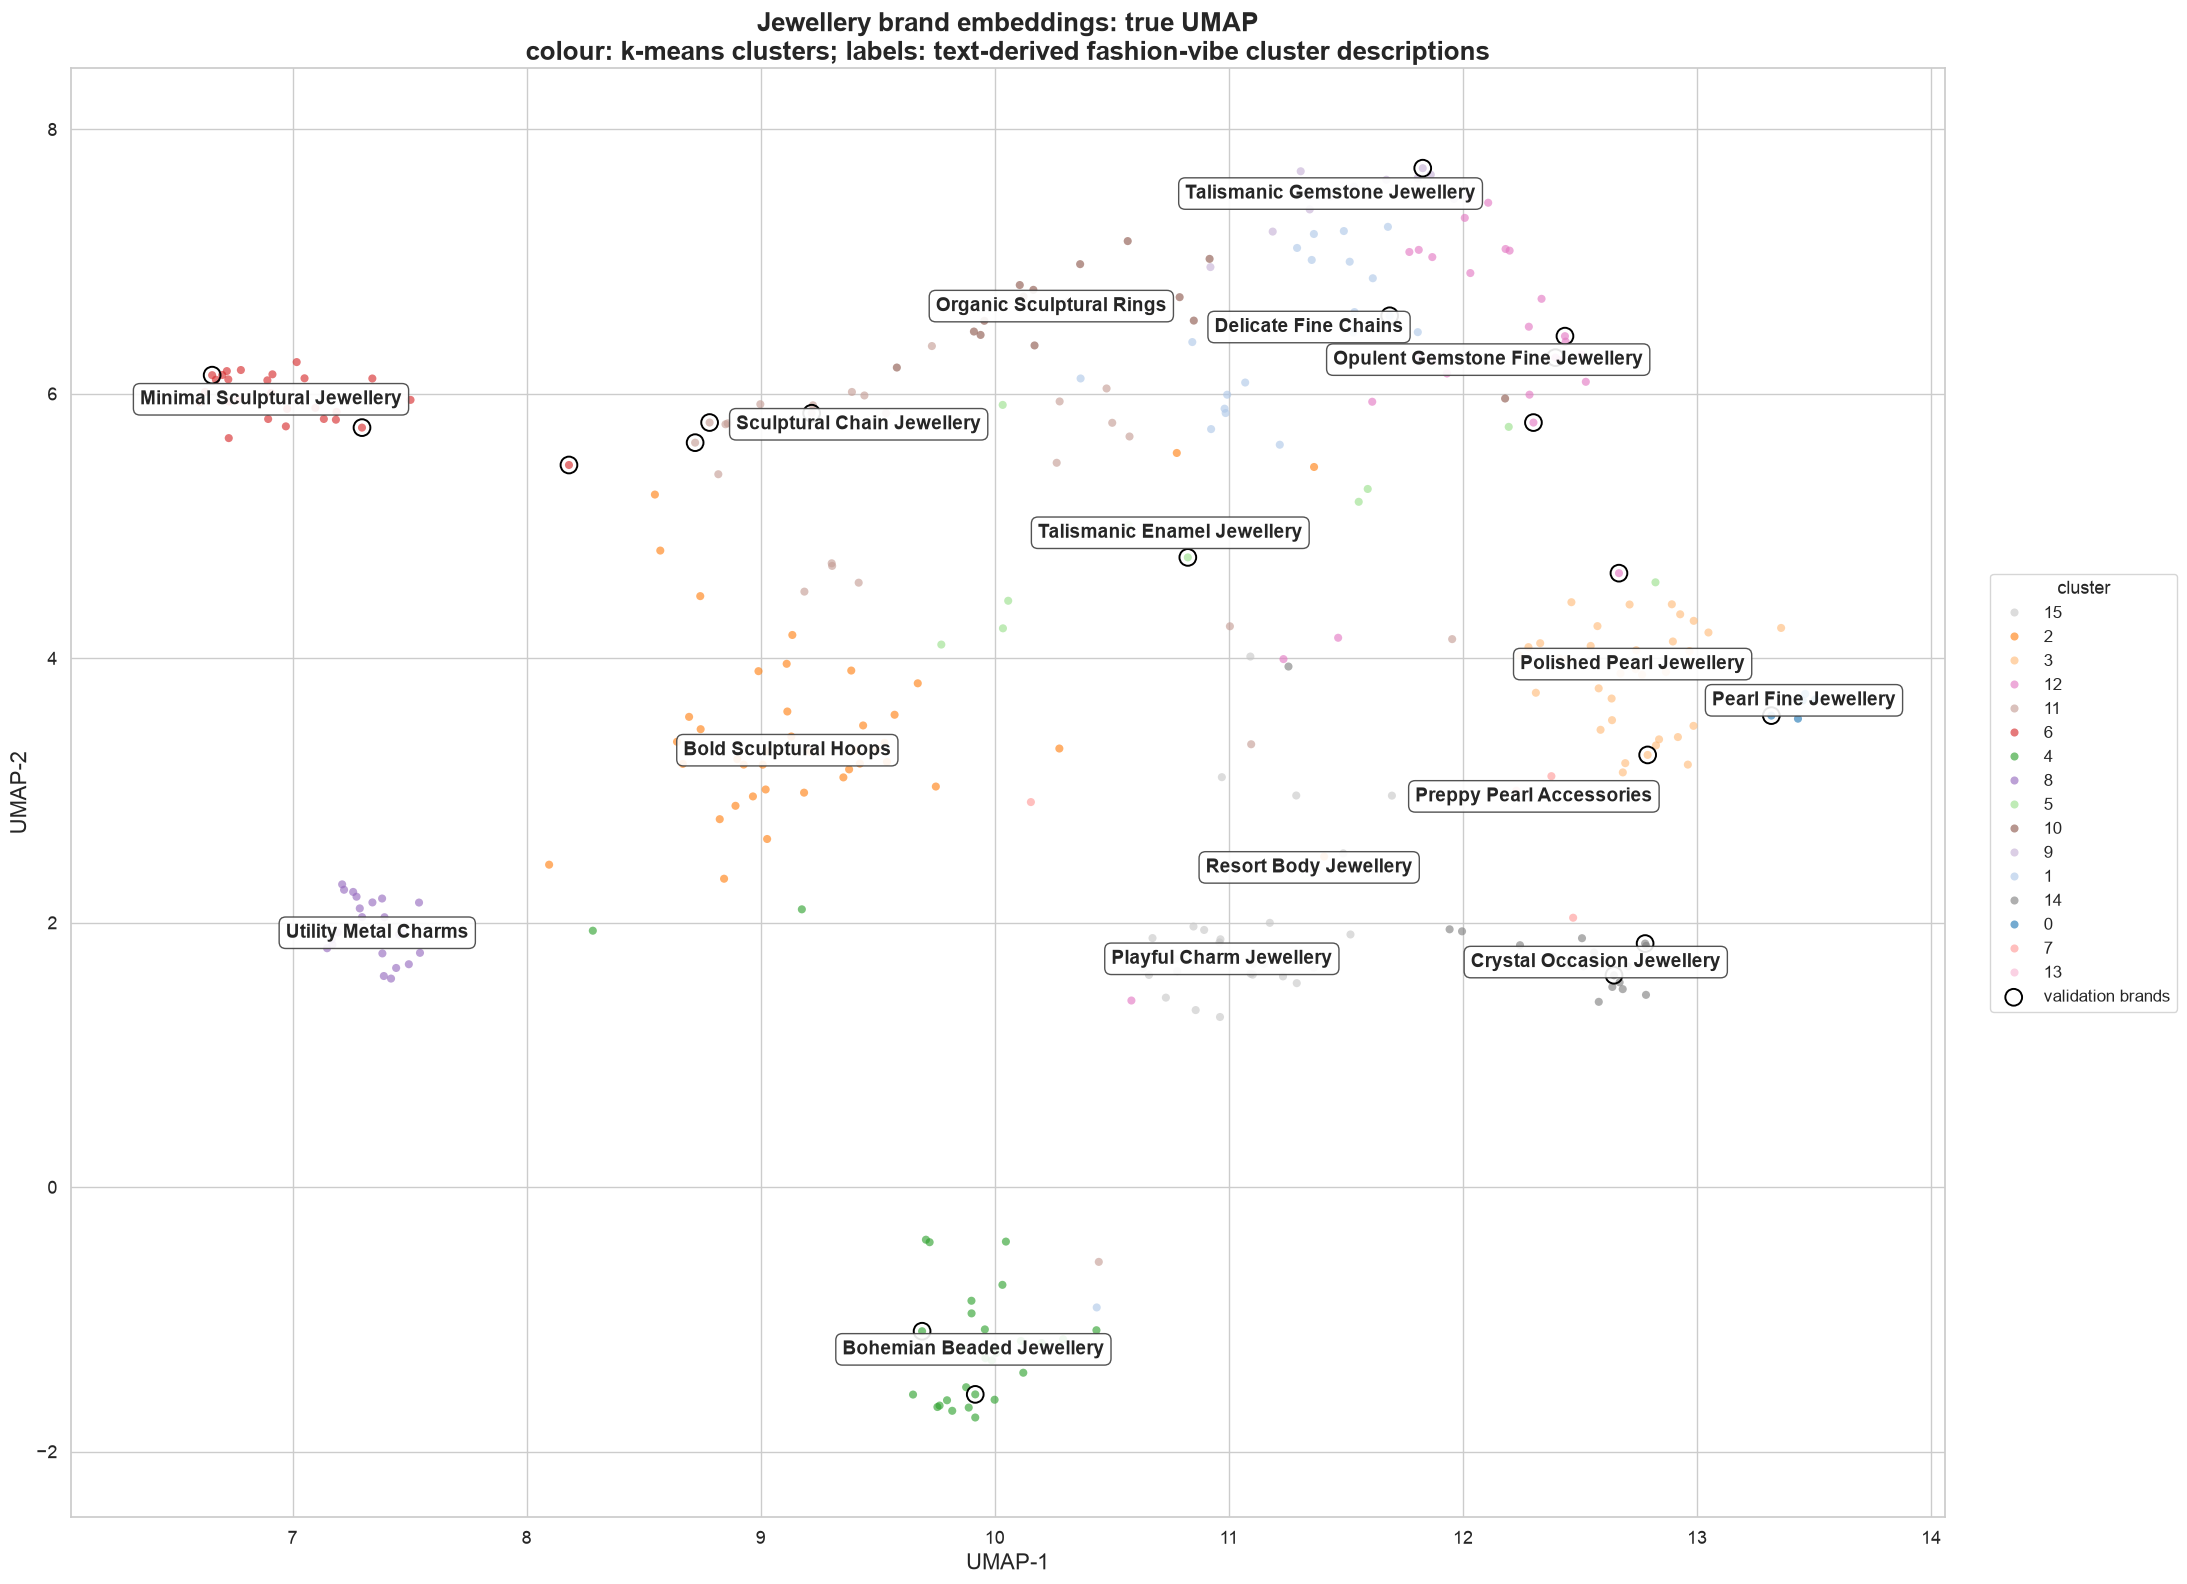

Moodboards matched for jewellery: 175 representative examples


,cluster,brand_name,centroid_similarity
0,0,YOKO LONDON,0.979588
1,0,Perle by Lola,0.971684
2,0,Blue Ocean Traders,0.970633
3,0,Sophie Bille Brahe,0.967311
4,0,Mikimoto,0.964757
5,0,Simone Rocha,0.962180
6,1,Jennifer Meyer,0.977195
7,1,Azlee,0.975117
8,1,Anne Sportun,0.972401
9,1,Zoe Chicco,0.970095


In [8]:
jewellery_results = run_category_analysis("jewellery")


## Figure files

This section creates cluster figures and summary tables from the four category results.


In [9]:
import runpy

cluster_figure_files = runpy.run_path(str(ROOT / "step_4_clustering" / "helpers" / "figure_exports" / "clustering_figures.py"), run_name="__main__")

cluster_selection = cluster_selection_table(ROOT)
cluster_algorithm_comparison = cluster_algorithm_table(ROOT)
save_table(cluster_selection, "cluster_selection_scores", ROOT)
save_table(cluster_algorithm_comparison, "cluster_algorithm_comparison", ROOT)

display(cluster_selection)
display(cluster_algorithm_comparison)


Running clustering export for clothes...


Running clustering export for shoes...


Running clustering export for bags...


Running clustering export for jewellery...


Saved cluster-selection figure.


...

Saving cluster cards for bags...


Saving cluster cards for jewellery...


Selected k values:
 category  selected_k  silhouette_best_k  davies_bouldin_best_k  selected_silhouette  selected_davies_bouldin  selected_score
  clothes          18                  8                     17             0.145821                 2.357177        0.815185
    shoes          24                 24                     24             0.230239                 1.682616        0.988889
     bags          17                 12                     17             0.235752                 1.859586        0.892353
jewellery          16                 18                     16             0.247916                 1.900831        0.846184
Saved clustering figures to thesis_text/figures


,category,brands,selected k,silhouette-best k,DB-best k,selected silhouette,selected DB,combined score
0,Clothes,746,18,8,17,0.145821,2.357177,0.815185
1,Shoes,316,24,24,24,0.230239,1.682616,0.988889
2,Bags,301,17,12,17,0.235752,1.859586,0.892353
3,Jewellery,326,16,18,16,0.247916,1.900831,0.846184


,category,method,clusters,noise,cosine silhouette
0,Clothes,k-means k=18,18,0,0.145821
1,Clothes,agglomerative k=18,18,0,0.167845
2,Clothes,HDBSCAN,4,207,0.170261
3,Shoes,k-means k=24,24,0,0.230239
4,Shoes,agglomerative k=24,24,0,0.231993
5,Shoes,HDBSCAN,12,147,0.466108
6,Bags,k-means k=17,17,0,0.235752
7,Bags,agglomerative k=17,17,0,0.141109
8,Bags,HDBSCAN,9,157,0.529555
9,Jewellery,k-means k=16,16,0,0.247916
